In [21]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
df = pd.read_csv("../dataset/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

# Load trained model
with open("../model/fraud_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully")

Model loaded successfully


In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")

print("Cross Validation AUC Scores:", scores)
print("Average AUC:", scores.mean())

Cross Validation AUC Scores: [0.94247204 0.96411089 0.9470575  0.99341992 0.98258902]
Average AUC: 0.9659298727929849


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (227845, 30)
Test size: (56962, 30)


In [26]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../dataset/creditcard.csv")

# Feature Engineering (same as training)
df['Log_Amount'] = np.log1p(df['Amount'])

df['Hour'] = (df['Time'] % 86400) / 3600
df['Hour_sin'] = np.sin(2*np.pi*df['Hour']/24)
df['Hour_cos'] = np.cos(2*np.pi*df['Hour']/24)

df['V1_V2'] = df['V1'] * df['V2']
df['V3_V4'] = df['V3'] * df['V4']

df['Amount_V1'] = df['Log_Amount'] * df['V1']
df['Amount_V14'] = df['Log_Amount'] * df['V14']

df.drop(columns=['Time','Amount'], inplace=True)

In [27]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
import pickle

with open("../model/fraud_model.pkl", "rb") as f:
    model = pickle.load(f)

In [31]:
import pickle

with open("../model/metrics.pkl","rb") as f:
    metrics = pickle.load(f)

feature_names = metrics["feature_names"]

X = df[feature_names]

In [32]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.9979635546504687
Precision: 0.4536082474226804
Recall: 0.8979591836734694
F1 Score: 0.6027397260273972
ROC-AUC: 0.9842852764347158


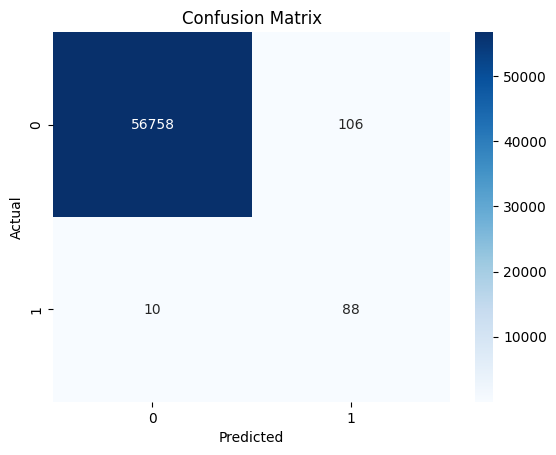

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

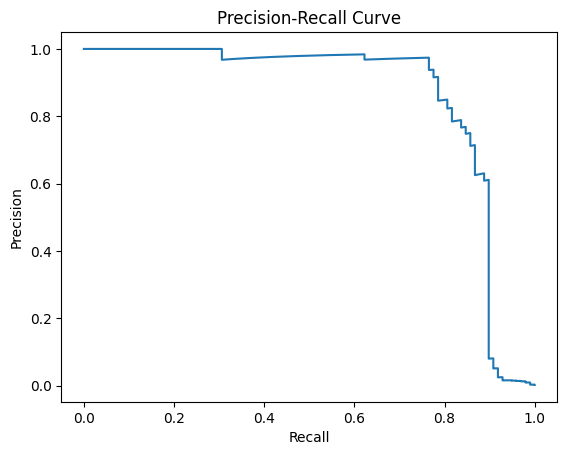

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

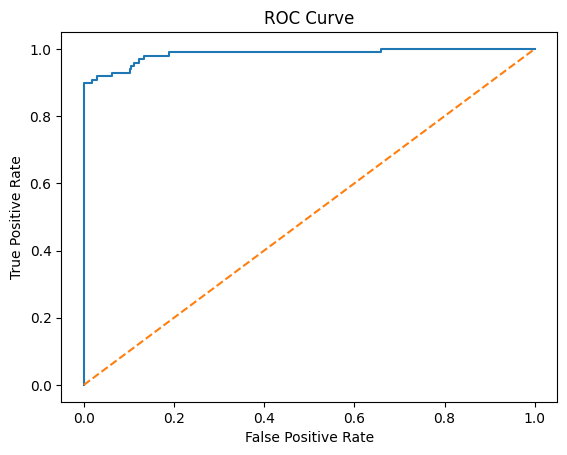

In [36]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [1]:
pip install xgboost lightgbm imbalanced-learn scipy -q

Note: you may need to restart the kernel to use updated packages.


Libraries loaded successfully
Dataset Created
         V1        V2        V3        V4        V5        V6        V7  \
0  0.496714 -0.138264  0.647689  1.523030 -0.234153 -0.234137  1.579213   
1 -0.600639 -0.291694 -0.601707  1.852278 -0.013497 -1.057711  0.822545   
2 -0.839218 -0.309212  0.331263  0.975545 -0.479174 -0.185659 -1.106335   
3 -0.808494 -0.501757  0.915402  0.328751 -0.529760  0.513267  0.097078   
4  0.060230  2.463242 -0.192361  0.301547 -0.034712 -1.168678  1.142823   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.767435 -0.469474  0.542560  ... -0.225776  0.067528 -1.424748 -0.544383   
1 -1.220844  0.208864 -1.959670  ... -1.763040  0.324084 -0.385082 -0.676922   
2 -1.196207  0.812526  1.356240  ... -0.299007  0.091761 -1.987569 -0.219672   
3  0.968645 -0.702053 -0.327662  ...  0.404051  1.886186  0.174578  0.257550   
4  0.751933  0.791032 -0.909387  ...  0.473592 -0.919424  1.549934 -0.783253   

        V26       V27 

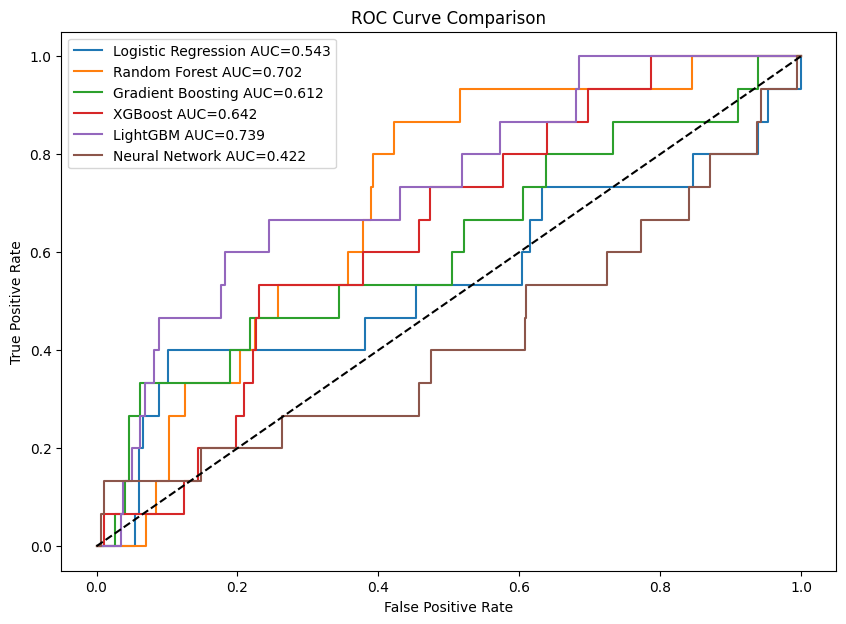

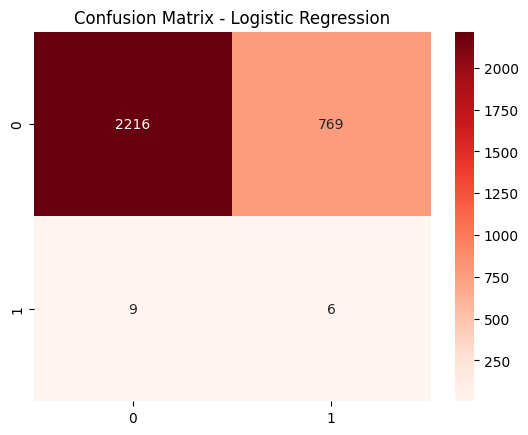


Best Model: Logistic Regression

Cross Validation
Logistic Regression Mean F1: 0.7708679235519093
Random Forest Mean F1: 0.9977078897224363
Gradient Boosting Mean F1: 0.9898988662113904
XGBoost Mean F1: 0.9974945012816694
[LightGBM] [Info] Number of positive: 5572, number of negative: 5572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001692 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 11144, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 5572, number of negative: 5572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 11144, number of 

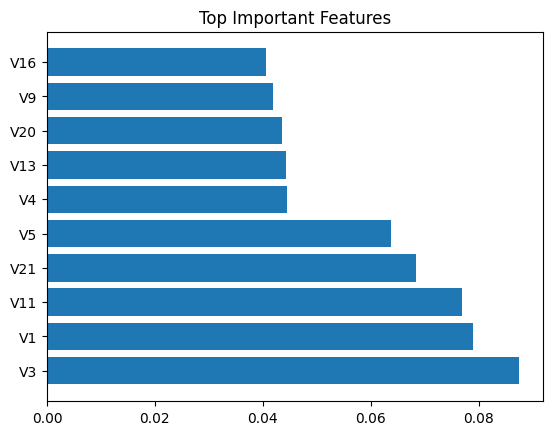


Model saved as fraud_model.pkl

Fraud Detection Analysis Completed


In [2]:
# ==========================================================
# FRAUD DETECTION MODEL - FULL UPDATED VERSION
# ==========================================================

# Install dependencies (important for Kaggle / Colab)


# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Save model
import joblib
import time

print("Libraries loaded successfully")

# ==========================================================
# 2. GENERATE DATASET
# ==========================================================

np.random.seed(42)

n_samples = 10000
n_features = 28

X = np.random.randn(n_samples, n_features)
y = np.zeros(n_samples)

fraud_indices = np.random.choice(n_samples, size=int(n_samples*0.005), replace=False)
y[fraud_indices] = 1

for idx in fraud_indices:
    X[idx,:5] += np.random.randn(5)*1.8

columns = [f"V{i}" for i in range(1,n_features+1)]

df = pd.DataFrame(X,columns=columns)

df["Amount"] = np.abs(np.random.exponential(100,n_samples))
df["Time"] = np.random.randint(0,172800,n_samples)

df["Class"] = y

print("Dataset Created")
print(df.head())

# ==========================================================
# 3. DATA PREPROCESSING
# ==========================================================

X = df.drop("Class",axis=1)
y = df["Class"]

scaler = RobustScaler()

X[['Amount','Time']] = scaler.fit_transform(X[['Amount','Time']])

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train Size:",len(X_train))
print("Test Size:",len(X_test))

# ==========================================================
# 4. HANDLE IMBALANCE
# ==========================================================

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train,y_train)

print("Balanced Dataset Size:",len(X_train_balanced))

# ==========================================================
# 5. DEFINE MODELS
# ==========================================================

models = {

"Logistic Regression": LogisticRegression(max_iter=1000),

"Random Forest": RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight="balanced",
    random_state=42
),

"Gradient Boosting": GradientBoostingClassifier(
    n_estimators=100
),

"XGBoost": XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric="logloss"
),

"LightGBM": LGBMClassifier(
    n_estimators=100
),

"Neural Network": MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=300
)

}

# ==========================================================
# 6. TRAIN MODELS
# ==========================================================

results = {}
predictions = {}

for name,model in models.items():

    print("\nTraining:",name)

    start = time.time()

    model.fit(X_train_balanced,y_train_balanced)

    train_time = time.time()-start

    y_pred = model.predict(X_test)

    # Safe probability
    if hasattr(model,"predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    predictions[name] = (y_pred,y_prob)

    results[name] = {

        "Accuracy": accuracy_score(y_test,y_pred),

        "Precision": precision_score(y_test,y_pred,zero_division=0),

        "Recall": recall_score(y_test,y_pred,zero_division=0),

        "F1": f1_score(y_test,y_pred,zero_division=0),

        "ROC-AUC": roc_auc_score(y_test,y_prob),

        "Time": train_time
    }

    print("F1:",results[name]["F1"])

# ==========================================================
# 7. RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(results).T

print("\nMODEL PERFORMANCE")
print(results_df)

# ==========================================================
# 8. ROC CURVE
# ==========================================================

plt.figure(figsize=(10,7))

for name in models:

    y_prob = predictions[name][1]

    fpr,tpr,_ = roc_curve(y_test,y_prob)

    auc = roc_auc_score(y_test,y_prob)

    plt.plot(fpr,tpr,label=f"{name} AUC={auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

# ==========================================================
# 9. CONFUSION MATRIX BEST MODEL
# ==========================================================

best_model_name = results_df["F1"].idxmax()

best_pred = predictions[best_model_name][0]

cm = confusion_matrix(y_test,best_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Reds")

plt.title("Confusion Matrix - "+best_model_name)

plt.show()

print("\nBest Model:",best_model_name)

# ==========================================================
# 10. CROSS VALIDATION
# ==========================================================

print("\nCross Validation")

skf = StratifiedKFold(n_splits=5)

for name,model in models.items():

    scores = cross_val_score(
        model,
        X_train_balanced,
        y_train_balanced,
        cv=skf,
        scoring="f1"
    )

    print(name,"Mean F1:",scores.mean())

# ==========================================================
# 11. FEATURE IMPORTANCE
# ==========================================================

rf = models["Random Forest"]

importances = rf.feature_importances_

indices = np.argsort(importances)[::-1][:10]

plt.barh(range(10),importances[indices])

plt.yticks(range(10),X.columns[indices])

plt.title("Top Important Features")

plt.show()

# ==========================================================
# 12. SAVE BEST MODEL
# ==========================================================

best_model = models[best_model_name]

joblib.dump(best_model,"fraud_model.pkl")

print("\nModel saved as fraud_model.pkl")

# ==========================================================
# COMPLETE
# ==========================================================

print("\nFraud Detection Analysis Completed")